In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from src.loading import load_gpm_feature_stats, load_dyamond

# GPM vs DYAMOND (0.05°): Feature Size Distributions

Compare the size distribution (`area_km2`) of precipitation features between the
GPM observations and the DYAMOND global storm-resolving models regridded to
**0.05°**, the resolution closest to GPM DPR's native ~5 km footprint. Only the
models processed to 0.05° so far are included.

## Swath truncation: why not `fits_in_swath`

The DYAMOND files carry a `fits_in_swath` column, but it does **not** mean what
the name suggests, and it is *not* comparable to anything in GPM:

- `fits_in_swath` is a **width** test — it is `True` whenever the feature's
  `cross_swath_extent_km` is under the ~245 km DPR swath width, regardless of
  where the feature actually sits. Essentially every feature passes it
  (~99.8% for ICON), so it discards almost nothing.
- GPM's `touches_cross_track_edge` is a **truncation** test — it is exactly
  `cross_track_edge_px > 0`, i.e. the feature was clipped by the swath edge.

Comparing one against the other would compare a width criterion to a truncation
criterion. Instead we use the **edge fraction**, which measures the same thing in
both datasets:

$$\mathrm{edge\_frac} = \frac{\text{edge pixels}}{\text{total feature pixels}}$$

- GPM → `cross_track_edge_px / size_px`
- DYAMOND → `swath_edge_px / size_px`

A feature with `edge_frac = 0` is fully interior; a large `edge_frac` means much
of the feature lies against the swath edge and its true extent is unknown
(it was cut off). Set `EDGE_FRAC_MAX` below to choose how much truncation to
tolerate — `0.0` keeps only untouched features, `1.0` keeps everything.

In [2]:
RESOLUTION = "0p05"

# Only these models have been processed to 0.05 deg so far.
DYAMOND_MODELS = [
    "GEOS-3km",
    "ICON-SAP-5km",
    "SHiELD-3km",
]

# Maximum tolerated fraction of a feature's pixels lying on the swath edge.
# 0.0 -> only fully interior features; 1.0 -> no filtering at all.
EDGE_FRAC_MAX = 0.05


def with_edge_frac(df: pl.DataFrame, edge_col: str) -> pl.DataFrame:
    """Add a normalised `edge_frac` = edge pixels / total feature pixels."""
    return df.with_columns(
        (pl.col(edge_col) / pl.col("size_px")).alias("edge_frac")
    )


feature_data = {}
feature_data["GPM"] = with_edge_frac(load_gpm_feature_stats(), "cross_track_edge_px")
for model in DYAMOND_MODELS:
    feature_data[model] = with_edge_frac(load_dyamond(model, RESOLUTION), "swath_edge_px")

# Observations -> black & thick; DYAMOND models -> color cycle.
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
plot_styles = {}
cycle_index = 0
for name in feature_data:
    if name == "GPM":
        plot_styles[name] = {"color": "black", "lw": 3.5, "ls": "-"}
    else:
        plot_styles[name] = {"color": color_cycle[cycle_index % len(color_cycle)], "lw": 1.8, "ls": "-"}
        cycle_index += 1

for name, df in feature_data.items():
    kept = (df["edge_frac"] <= EDGE_FRAC_MAX).mean()
    print(
        f"{name:15s} n={df.height:7d}  untouched={(df['edge_frac'] == 0).mean():.3f}"
        f"  kept(edge_frac<={EDGE_FRAC_MAX:.2f})={kept:.3f}"
    )

GPM             n=  79512  untouched=0.726  kept(edge_frac<=0.05)=0.804
GEOS-3km        n= 400416  untouched=0.791  kept(edge_frac<=0.05)=0.828
ICON-SAP-5km    n= 741866  untouched=0.846  kept(edge_frac<=0.05)=0.858
SHiELD-3km      n= 299259  untouched=0.756  kept(edge_frac<=0.05)=0.811


## Sensitivity to the edge-fraction threshold

Before picking a threshold, check what it costs and what it changes. The left
panel shows how much of each dataset survives the cut; the right shows how the
median feature size responds. A threshold sitting on a steep part of these curves
means the results depend strongly on an arbitrary choice — prefer one on a flat
part.

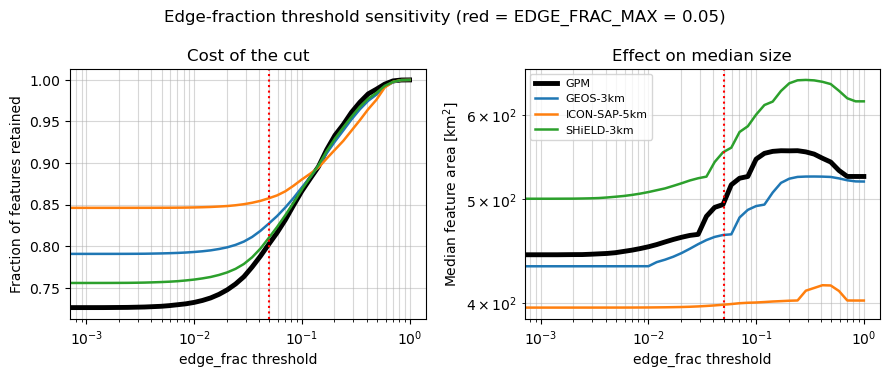

In [3]:
thresholds = np.concatenate([[0.0], np.logspace(-3, 0, 40)])

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))

for name, df in feature_data.items():
    ef = df["edge_frac"].to_numpy()
    area = df["area_km2"].to_numpy()
    kept = [(ef <= t).mean() for t in thresholds]
    med = [np.median(area[ef <= t]) if (ef <= t).any() else np.nan for t in thresholds]
    axes[0].plot(thresholds, kept, label=name, **plot_styles[name])
    axes[1].plot(thresholds, med, label=name, **plot_styles[name])

for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel("edge_frac threshold")
    ax.axvline(EDGE_FRAC_MAX, color="red", ls=":", lw=1.5)
    ax.grid(alpha=0.5, which="both")

axes[0].set_ylabel("Fraction of features retained")
axes[0].set_title("Cost of the cut")
axes[1].set_yscale("log")
axes[1].set_ylabel("Median feature area [km$^2$]")
axes[1].set_title("Effect on median size")
axes[1].legend(fontsize=8)
fig.suptitle(f"Edge-fraction threshold sensitivity (red = EDGE_FRAC_MAX = {EDGE_FRAC_MAX})")
fig.tight_layout()

## Distribution helpers

`plot_cdf` and `plot_pdf` as in the 0.1° notebook. The PDF is a density with
respect to `log10(area)` on log-spaced bins, with bin width set per decade —
feature area is quantised (`area ~ size_px * pixel_area`), so bins much finer
than ~6 per decade resolve individual pixel counts and produce a sawtooth.

In [4]:
def plot_cdf(series: pl.Series, ax: plt.Axes = None, label: str = None, **kwargs):
    values = series.drop_nulls().sort().to_numpy()
    cdf = np.arange(1, len(values) + 1) / len(values)
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.get_figure()
    ax.plot(values, cdf, label=label, **kwargs)
    return fig, ax


def log_bins(datasets, bins_per_decade: int = 6):
    """Shared log10-spaced bin edges spanning every dataset passed in."""
    lo = min(float(d.min()) for d in datasets if d.len() > 0)
    hi = max(float(d.max()) for d in datasets if d.len() > 0)
    lo10, hi10 = np.log10(lo), np.log10(hi)
    n_bins = max(1, int(round((hi10 - lo10) * bins_per_decade)))
    return np.linspace(lo10, hi10, n_bins + 1)


def plot_pdf(series: pl.Series, ax: plt.Axes = None, label: str = None,
             bins: np.ndarray = None, **kwargs):
    """Density of log10(area), plotted at bin centres on a log x-axis."""
    values = series.drop_nulls().to_numpy()
    values = values[values > 0]
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.get_figure()
    counts, edges = np.histogram(np.log10(values), bins=bins, density=True)
    centers = 10 ** (0.5 * (edges[:-1] + edges[1:]))
    ax.plot(centers, counts, label=label, **kwargs)
    return fig, ax


# Left panel: everything. Right panel: only features whose truncation by the
# swath edge is below the tolerance set above.
subsets = {
    "All features": lambda df: df,
    f"edge_frac <= {EDGE_FRAC_MAX:g}": lambda df: df.filter(pl.col("edge_frac") <= EDGE_FRAC_MAX),
}

## Size distribution (CDF)

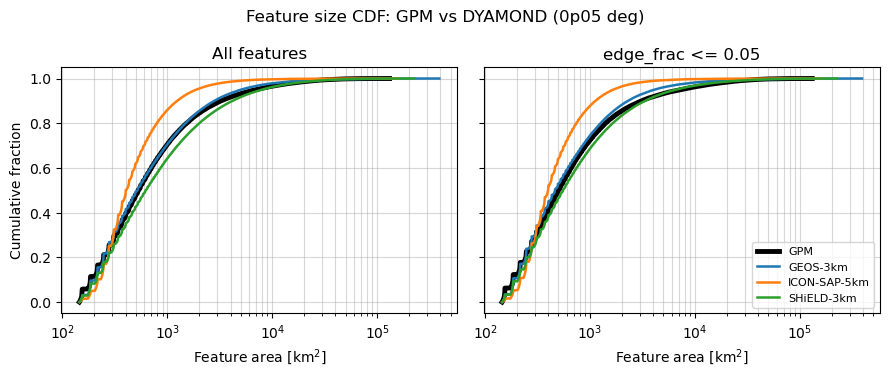

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)

for ax, (title, subset) in zip(axes, subsets.items()):
    for name, df in feature_data.items():
        plot_cdf(subset(df)["area_km2"], ax=ax, label=name, **plot_styles[name])
    ax.set_xscale("log")
    ax.set_xlabel("Feature area [km$^2$]")
    ax.set_title(title)
    ax.grid(alpha=0.5, which="both")

axes[0].set_ylabel("Cumulative fraction")
axes[1].legend(loc="lower right", fontsize=8)
fig.suptitle(f"Feature size CDF: GPM vs DYAMOND ({RESOLUTION} deg)")
fig.tight_layout()

## Size distribution (PDF)

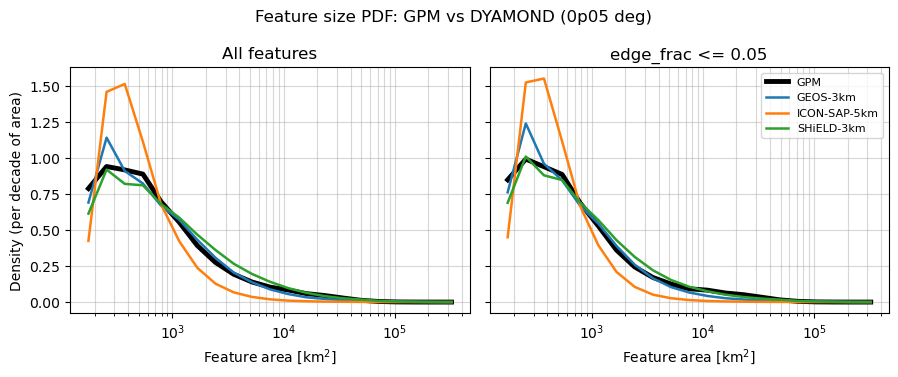

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)

for ax, (title, subset) in zip(axes, subsets.items()):
    series = [subset(df)["area_km2"] for df in feature_data.values()]
    bins = log_bins(series)
    for name, df in feature_data.items():
        plot_pdf(subset(df)["area_km2"], ax=ax, label=name, bins=bins, **plot_styles[name])
    ax.set_xscale("log")
    ax.set_xlabel("Feature area [km$^2$]")
    ax.set_title(title)
    ax.grid(alpha=0.5, which="both")

axes[0].set_ylabel("Density (per decade of area)")
axes[1].legend(loc="upper right", fontsize=8)
fig.suptitle(f"Feature size PDF: GPM vs DYAMOND ({RESOLUTION} deg)")
fig.tight_layout()

## Small features only

Restricted to features smaller than `1e4 km^2`. Bins are recomputed over this
restricted range and each curve renormalised within it, so these are
distributions *conditional on* being a small feature — the printed fractions
below say how much of each dataset that actually covers.

GPM             frac(area < 1e+04 km2) = 0.966
GEOS-3km        frac(area < 1e+04 km2) = 0.979
ICON-SAP-5km    frac(area < 1e+04 km2) = 0.997
SHiELD-3km      frac(area < 1e+04 km2) = 0.962


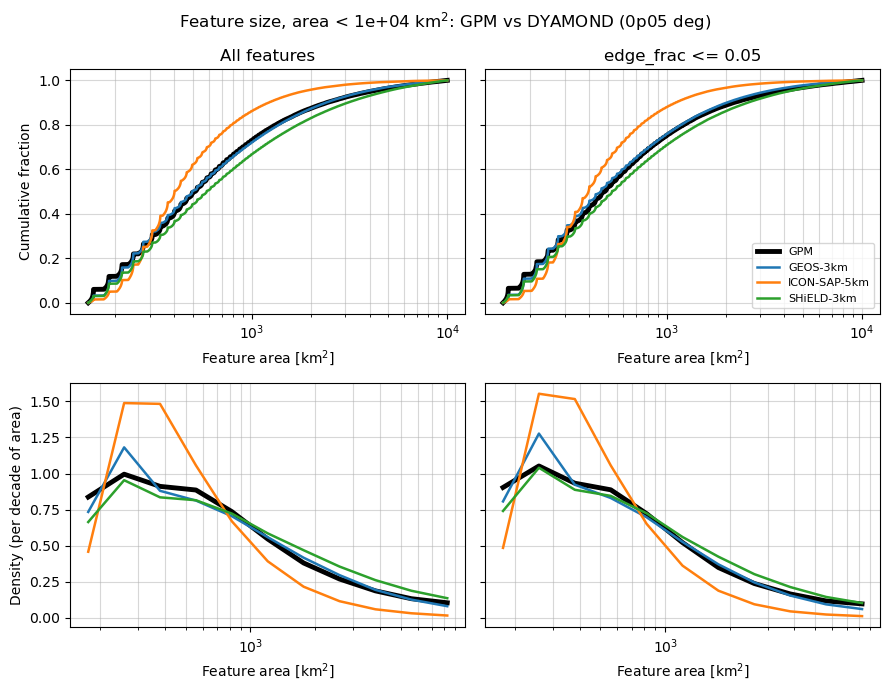

In [7]:
AREA_MAX = 1e4  # km^2

subsets_small = {
    "All features": lambda df: df.filter(pl.col("area_km2") < AREA_MAX),
    f"edge_frac <= {EDGE_FRAC_MAX:g}": lambda df: df.filter(
        (pl.col("edge_frac") <= EDGE_FRAC_MAX) & (pl.col("area_km2") < AREA_MAX)
    ),
}

fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharey="row")

for col, (title, subset) in enumerate(subsets_small.items()):
    ax = axes[0, col]
    for name, df in feature_data.items():
        plot_cdf(subset(df)["area_km2"], ax=ax, label=name, **plot_styles[name])
    ax.set_title(title)
    ax.set_ylabel("Cumulative fraction" if col == 0 else "")

    ax = axes[1, col]
    series = [subset(df)["area_km2"] for df in feature_data.values()]
    bins = log_bins(series)
    for name, df in feature_data.items():
        plot_pdf(subset(df)["area_km2"], ax=ax, label=name, bins=bins, **plot_styles[name])
    ax.set_ylabel("Density (per decade of area)" if col == 0 else "")

for ax in axes.ravel():
    ax.set_xscale("log")
    ax.set_xlabel("Feature area [km$^2$]")
    ax.grid(alpha=0.5, which="both")

axes[0, 1].legend(loc="lower right", fontsize=8)
fig.suptitle(f"Feature size, area < {AREA_MAX:.0e} km$^2$: GPM vs DYAMOND ({RESOLUTION} deg)")
fig.tight_layout()

for name, df in feature_data.items():
    frac = (df["area_km2"] < AREA_MAX).mean()
    print(f"{name:15s} frac(area < {AREA_MAX:.0e} km2) = {frac:.3f}")

## Median feature size

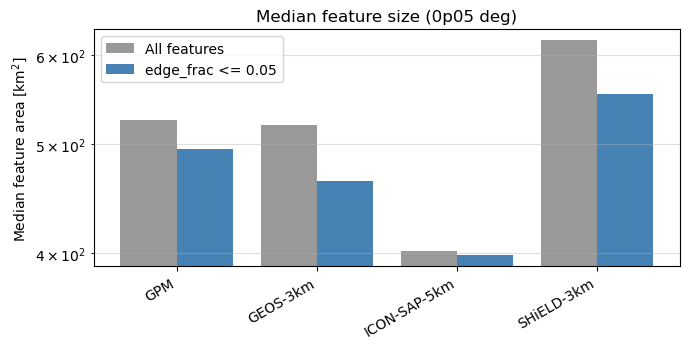

In [8]:
names = list(feature_data.keys())
med_all = [feature_data[n]["area_km2"].median() for n in names]
med_cut = [
    feature_data[n].filter(pl.col("edge_frac") <= EDGE_FRAC_MAX)["area_km2"].median()
    for n in names
]

x = np.arange(len(names))
w = 0.4
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(x - w / 2, med_all, w, label="All features", color="0.6")
ax.bar(x + w / 2, med_cut, w, label=f"edge_frac <= {EDGE_FRAC_MAX:g}", color="steelblue")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha="right")
ax.set_ylabel("Median feature area [km$^2$]")
ax.set_title(f"Median feature size ({RESOLUTION} deg)")
ax.legend()
ax.grid(alpha=0.4, axis="y", which="both")
fig.tight_layout()